# XGBoost Bayesian Optimization and Explainability

**Project:** Advanced Ensemble Boosting for Diabetes Prediction  
**Environment:** Google Colab  
**Dataset used:** `diabetes_012_health_indicators_BRFSS2015.csv` only  
**Primary paper:** Khurshid MR, Manzoor S, Sadiq T, Hussain L, Khan MS, Dutta AK (2025), *Unveiling diabetes onset: Optimized XGBoost with Bayesian optimization for enhanced prediction*, PLOS ONE 20(1): e0310218. https://doi.org/10.1371/journal.pone.0310218

## What this notebook covers
- Data loading, cleaning, preprocessing, and EDA on the BRFSS dataset.
- XGBoost with Bayesian hyperparameter optimization, following the paper's main modeling idea.
- Feature selection diagnostics using correlation, ANOVA F-test, mutual information, preliminary permutation importance, and feature-set validation.
- Model evaluation with accuracy, sensitivity/recall, specificity, PPV/precision, NPV, F1, MCC, ROC AUC, and PR AUC.
- Explainability with XGBoost importance, SHAP, LIME, permutation importance, drop-column importance, PDP, ICE, ALE, and interaction H-statistics.

In [1]:
!pip -q install xgboost shap scikit-optimize imbalanced-learn lime

import os
import warnings
warnings.filterwarnings("ignore")

from itertools import combinations
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from skopt import BayesSearchCV
from skopt.space import Integer, Real

from xgboost import XGBClassifier
import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42

# Runtime controls. Increase BAYES_ITERATIONS for a longer final Colab run.
BAYES_ITERATIONS = 50
CV_SPLITS = 5
FEATURE_SELECTION_SAMPLE_LIMIT = 90000
PRELIMINARY_IMPORTANCE_SAMPLE_SIZE = 5000
DROP_COLUMN_SAMPLE_LIMIT = 90000
EXPLAIN_SAMPLE_SIZE = 1500
ICE_SAMPLE_SIZE = 300
HSTAT_BACKGROUND_SIZE = 500
DROP_COLUMN_TOP_N = 10
HSTAT_TOP_N = 5
LIME_TRAIN_SAMPLE_SIZE = 5000

MODEL_SELECTION_SCORING = "roc_auc"
FEATURE_SET_SELECTION_METRIC = "accuracy_at_0_50"
PRIMARY_THRESHOLD_METRIC = "accuracy"

# Removed from the dataset/model after reviewing weak correlation or negative/low model impact.
FEATURES_TO_REMOVE = [
    "income",
    "fruits",
    "veggies",
    "menthlth",
    "anyhealthcare",
    "nodocbccost",
    "hvyalcoholconsump",
    "physactivity",
    "education",
]

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 9.6 MB/s eta 0:00:00


## 1. Data Loading and Cleaning

The loader checks for the dataset in common Colab and repository paths. It standardizes column names, creates a binary `diabetes_binary` target, removes duplicate rows, and adds schema-aware engineered features.

In [2]:
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")

# Standardize names once so every later cell is consistent.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("Original shape:", df.shape)
display(df.head())

df["diabetes_012"] = df["diabetes_012"].astype(int)
df["diabetes_binary"] = (df["diabetes_012"] > 0).astype(int)
df = df.drop(columns=["diabetes_012"])

print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).rename("missing_values"))

duplicate_count = int(df.duplicated().sum())
print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

# No feature engineering is used. Remove weak/low-impact original columns before modeling.
removed_columns = [column for column in FEATURES_TO_REMOVE if column in df.columns]
df = df.drop(columns=removed_columns)
print("Removed columns:", removed_columns)

df["diabetes_binary"] = df["diabetes_binary"].astype(int)

print("Cleaned shape:", df.shape)
print("Target distribution:")
display(df["diabetes_binary"].value_counts().rename("count"))

print("Target distribution percentage:")
display(
    (df["diabetes_binary"].value_counts(normalize=True) * 100)
    .round(2)
    .rename("percentage")
)

display(df.head())

Original shape: (253680, 22)


,diabetes_012,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,...,anyhealthcare,nodocbccost,genhlth,menthlth,physhlth,diffwalk,sex,age,education,income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Missing values:


,missing_values
highbp,0
highchol,0
cholcheck,0
bmi,0
smoker,0
stroke,0
heartdiseaseorattack,0
physactivity,0
fruits,0
veggies,0


Duplicate rows: 23968
Removed columns: ['income', 'fruits', 'veggies', 'menthlth', 'anyhealthcare', 'nodocbccost', 'hvyalcoholconsump', 'physactivity', 'education']
Cleaned shape: (229712, 13)
Target distribution:


,count
diabetes_binary,
0,190055
1,39657


Target distribution percentage:


,percentage
diabetes_binary,
0,82.74
1,17.26


,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,genhlth,physhlth,diffwalk,sex,age,diabetes_binary
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,5.0,15.0,1.0,0.0,9.0,0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,7.0,0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,5.0,30.0,1.0,0.0,9.0,0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,11.0,0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,11.0,0


## 2. EDA for XGBoost Modeling

The EDA focuses on class imbalance, diabetes rate by important health indicators, missingness, duplicated rows, class-level summaries, and correlation patterns. These diagnostics guide feature selection and threshold choices later.

,diabetes_binary,count,share
0,0,190055,0.827362
1,1,39657,0.172638


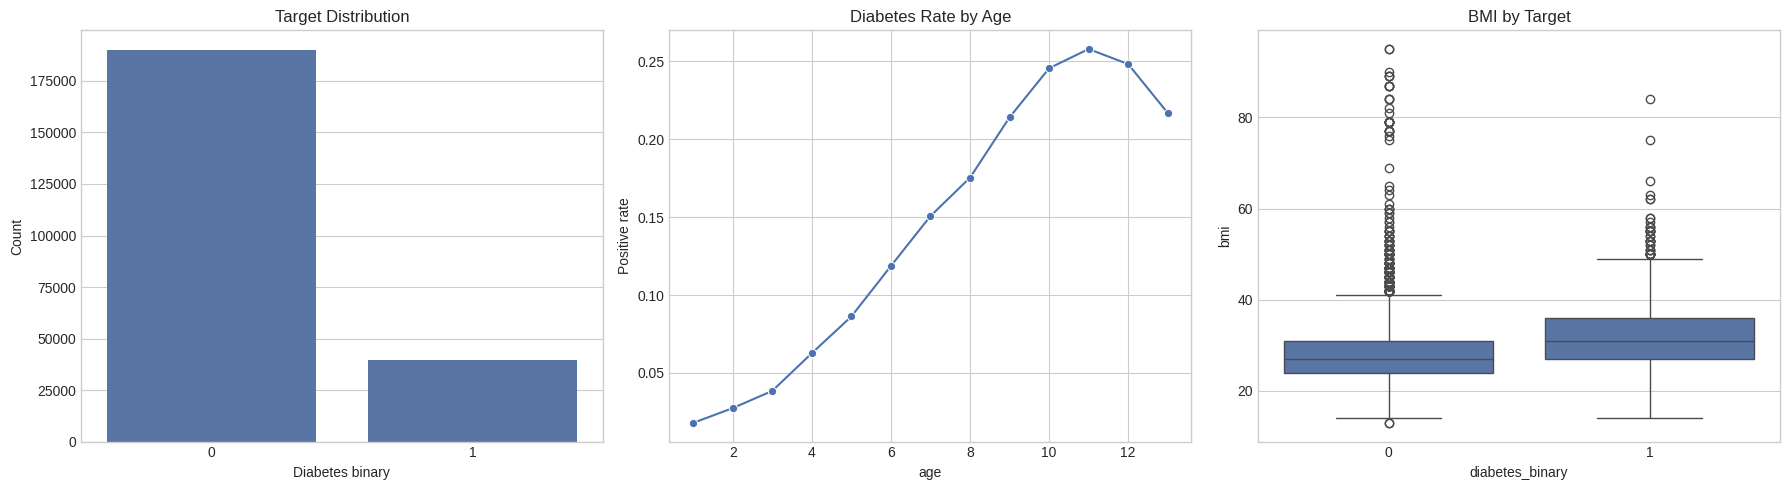

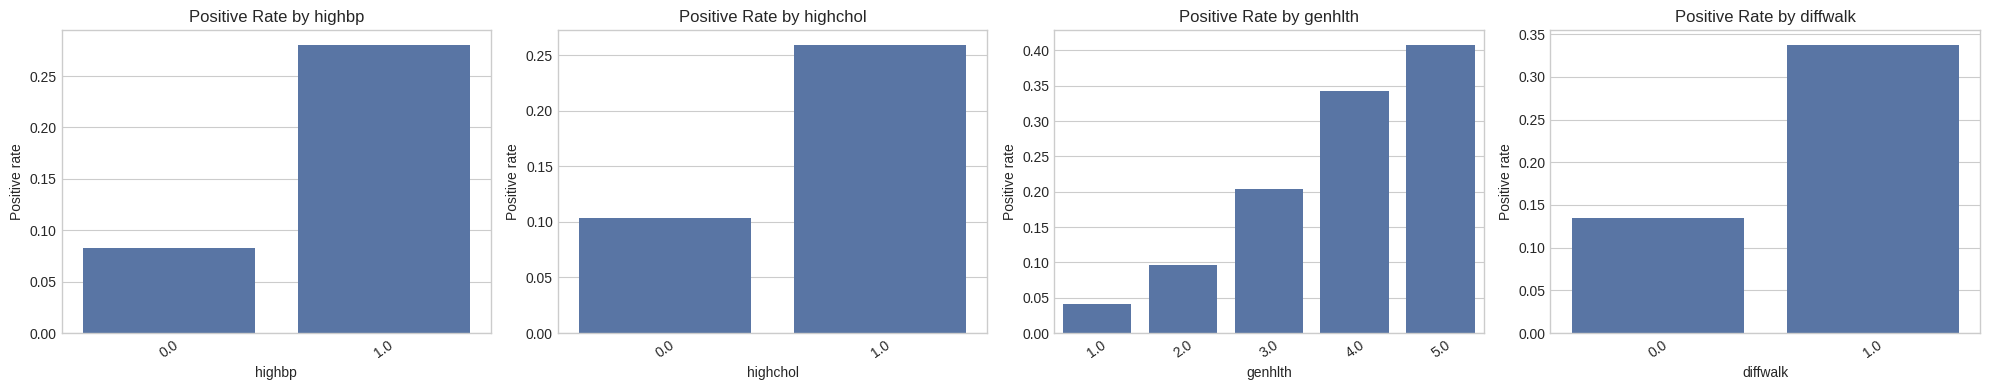

diabetes_binary           0          1
age       mean     7.824230   9.340419
          median   8.000000  10.000000
          std      3.161819   2.374213
bmi       mean    28.030528  31.825655
          median  27.000000  31.000000
          std      6.474981   7.347691
genhlth   mean     2.463724   3.260080
          median   2.000000   3.000000
          std      1.022137   1.017617
physhlth  mean     4.018805   7.828051
          median   0.000000   1.000000
          std      8.375376  11.223553
highbp    mean     0.395175   0.738104
          median   0.000000   1.000000
          std      0.488890   0.439672
highchol  mean     0.395349   0.663817
          median   0.000000   1.000000
          std      0.488927   0.472408
diffwalk  mean     0.148520   0.363063
          median   0.000000   0.000000
          std      0.355616   0.480889
cholcheck mean     0.952672   0.992359
          median   1.000000   1.000000
          std      0.212341   0.087077

,correlation_with_target
genhlth,0.282661
highbp,0.260295
bmi,0.211328
diffwalk,0.208574
highchol,0.204321
age,0.185205
heartdiseaseorattack,0.167333
physhlth,0.159122
stroke,0.097857
cholcheck,0.076110


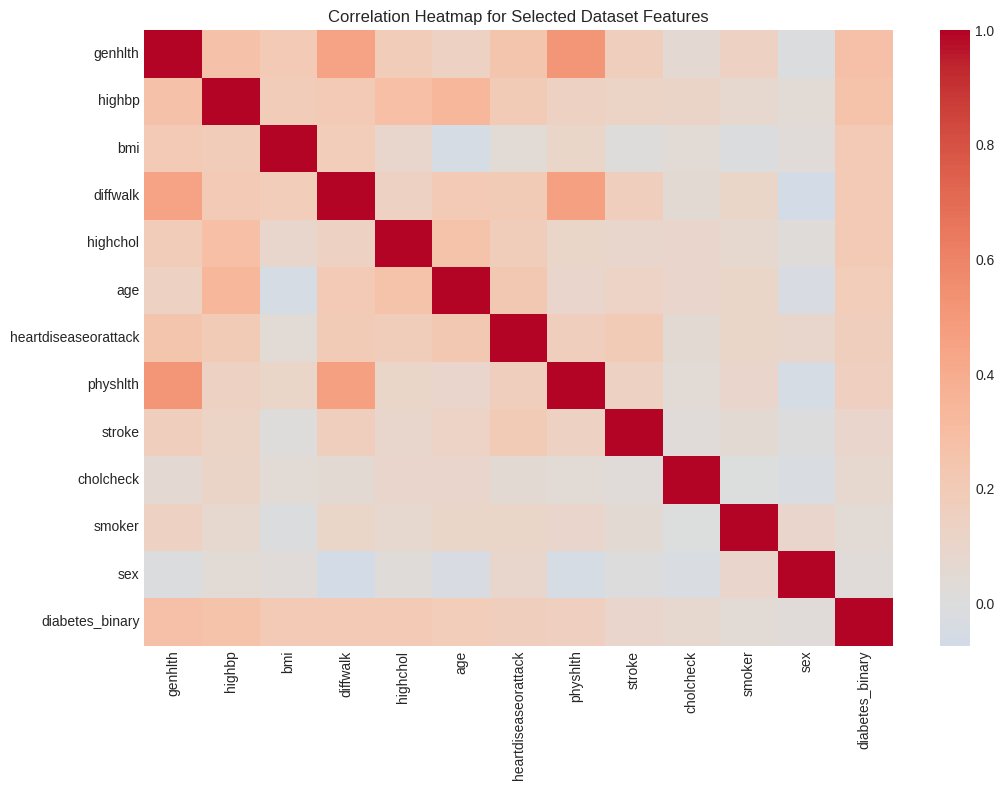

In [3]:
def encode_for_univariate(frame):
    encoded = frame.copy()
    for column in encoded.columns:
        if encoded[column].dtype == "object" or str(encoded[column].dtype).startswith("category"):
            encoded[column] = encoded[column].fillna("missing").astype(str)
            encoded[column] = pd.factorize(encoded[column])[0]
        else:
            encoded[column] = pd.to_numeric(encoded[column], errors="coerce")
    return encoded


def available(columns):
    return [column for column in columns if column in df.columns]


target_table = (
    df["diabetes_binary"].value_counts()
    .rename_axis("diabetes_binary")
    .reset_index(name="count")
)
target_table["share"] = target_table["count"] / len(df)
display(target_table)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="diabetes_binary", ax=axes[0])
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Diabetes binary")
axes[0].set_ylabel("Count")

age_rate = df.groupby("age", as_index=False)["diabetes_binary"].mean()
sns.lineplot(data=age_rate, x="age", y="diabetes_binary", marker="o", ax=axes[1])
axes[1].set_title("Diabetes Rate by Age")
axes[1].set_ylabel("Positive rate")

sns.boxplot(data=df.sample(min(10000, len(df)), random_state=RANDOM_STATE), x="diabetes_binary", y="bmi", ax=axes[2])
axes[2].set_title("BMI by Target")

plt.tight_layout()
plt.show()

rate_features = available([
    "highbp",
    "highchol",
    "genhlth",
    "diffwalk",
    "stroke",
    "heartdiseaseorattack",
])

if rate_features:
    plot_count = min(4, len(rate_features))
    fig, axes = plt.subplots(1, plot_count, figsize=(5 * plot_count, 4))
    if plot_count == 1:
        axes = [axes]
    for axis, feature in zip(axes, rate_features[:plot_count]):
        rate_table = df.groupby(feature, as_index=False)["diabetes_binary"].mean().sort_values(feature)
        sns.barplot(data=rate_table, x=feature, y="diabetes_binary", ax=axis)
        axis.set_title(f"Positive Rate by {feature}")
        axis.set_ylabel("Positive rate")
        axis.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()

numeric_columns = df.drop(columns="diabetes_binary").select_dtypes(include=np.number).columns.tolist()
summary_columns = available([
    "age",
    "bmi",
    "genhlth",
    "physhlth",
    "highbp",
    "highchol",
    "diffwalk",
    "cholcheck",
])
if not summary_columns:
    summary_columns = numeric_columns[:10]

class_summary = df.groupby("diabetes_binary")[summary_columns].agg(["mean", "median", "std"]).T
display(class_summary)

encoded_for_corr = encode_for_univariate(df.drop(columns="diabetes_binary"))
encoded_for_corr["diabetes_binary"] = df["diabetes_binary"].values
corr_to_target = (
    encoded_for_corr
    .corr(numeric_only=True)["diabetes_binary"]
    .drop("diabetes_binary")
    .sort_values(key=np.abs, ascending=False)
)
display(corr_to_target.rename("correlation_with_target"))

corr_features = corr_to_target.head(12).index.tolist() + ["diabetes_binary"]
plt.figure(figsize=(11, 8))
sns.heatmap(encoded_for_corr[corr_features].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap for Selected Dataset Features")
plt.tight_layout()
plt.show()

## 3. Train/Test Split and Feature Selection Diagnostics

ANOVA and mutual information are fitted only on the training split to avoid test leakage. A small XGBoost scorecard compares candidate feature sets before the final Bayesian search.

Training rows: 183769
Test rows: 45943
Modeling feature count: 12
Modeling features: ['highbp', 'highchol', 'cholcheck', 'bmi', 'smoker', 'stroke', 'heartdiseaseorattack', 'genhlth', 'physhlth', 'diffwalk', 'sex', 'age']


,feature,anova_f,anova_p_value,mutual_information,target_correlation,abs_target_correlation,anova_rank,mi_rank,corr_rank,average_rank
0,genhlth,15999.026873,0.000000e+00,0.041114,0.283000,0.283000,1.0,1.0,1.0,1.000000
1,highbp,13354.004514,0.000000e+00,0.034566,0.260279,0.260279,2.0,2.0,2.0,2.000000
2,bmi,8586.179604,0.000000e+00,0.028735,0.211276,0.211276,3.0,3.0,3.0,3.000000
3,diffwalk,8309.995274,0.000000e+00,0.018921,0.208000,0.208000,4.0,6.0,4.0,4.666667
4,highchol,7891.960098,0.000000e+00,0.020599,0.202921,0.202921,5.0,5.0,5.0,5.000000
5,age,6650.745190,0.000000e+00,0.023172,0.186888,0.186888,6.0,4.0,6.0,5.333333
6,heartdiseaseorattack,5396.579573,0.000000e+00,0.011960,0.168904,0.168904,7.0,8.0,7.0,7.333333
7,physhlth,4788.661322,0.000000e+00,0.013276,0.159363,0.159363,8.0,7.0,8.0,7.666667
8,stroke,1796.422988,0.000000e+00,0.004037,0.098392,0.098392,9.0,9.0,9.0,9.000000
9,cholcheck,1050.840921,7.157129e-230,0.003959,0.075404,0.075404,10.0,10.0,10.0,10.000000


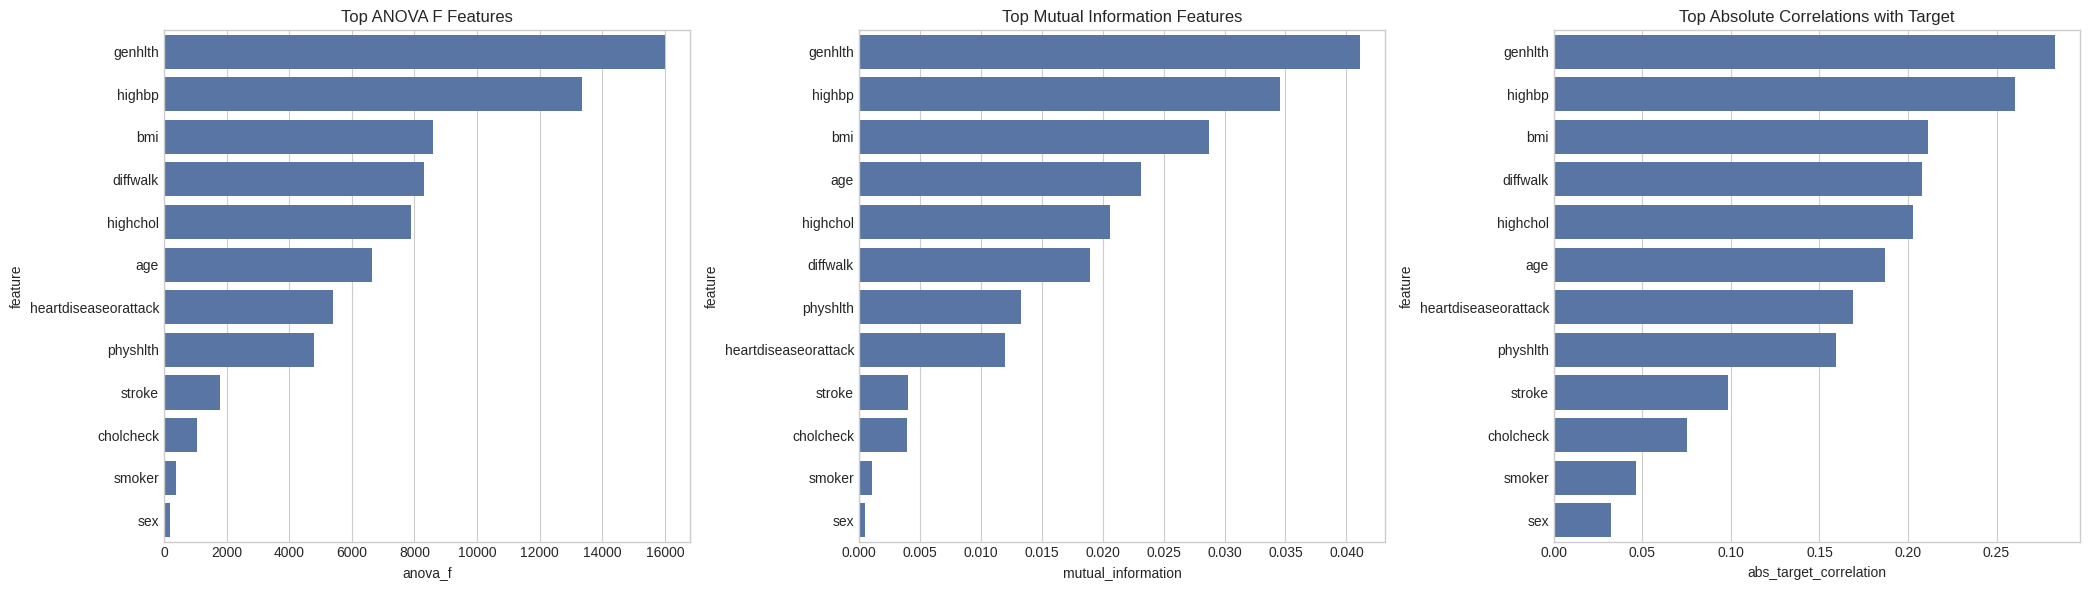

In [4]:
X = df.drop(columns="diabetes_binary")
y = df["diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

all_features = X_train.columns.tolist()
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Modeling feature count:", len(all_features))
print("Modeling features:", all_features)

X_train_rank = encode_for_univariate(X_train)
X_train_rank = X_train_rank.replace([np.inf, -np.inf], np.nan)
X_train_rank = X_train_rank.fillna(X_train_rank.median(numeric_only=True))

categorical_or_discrete = np.array([
    (X_train[column].dtype == "object")
    or str(X_train[column].dtype).startswith("category")
    or (X_train[column].nunique(dropna=True) <= 20)
    for column in X_train.columns
])

anova_f_values, anova_p_values = f_classif(X_train_rank, y_train)
mi_values = mutual_info_classif(
    X_train_rank,
    y_train,
    random_state=RANDOM_STATE,
    discrete_features=categorical_or_discrete,
)

rank_corr_frame = X_train_rank.copy()
rank_corr_frame["diabetes_binary"] = y_train.values
target_correlation = rank_corr_frame.corr(numeric_only=True)["diabetes_binary"].drop("diabetes_binary")

feature_ranking = pd.DataFrame({
    "feature": X_train.columns,
    "anova_f": anova_f_values,
    "anova_p_value": anova_p_values,
    "mutual_information": mi_values,
    "target_correlation": target_correlation.reindex(X_train.columns).values,
})
feature_ranking["abs_target_correlation"] = feature_ranking["target_correlation"].abs()

feature_ranking["anova_rank"] = feature_ranking["anova_f"].rank(ascending=False, method="min")
feature_ranking["mi_rank"] = feature_ranking["mutual_information"].rank(ascending=False, method="min")
feature_ranking["corr_rank"] = feature_ranking["abs_target_correlation"].rank(ascending=False, method="min")
feature_ranking["average_rank"] = (
    feature_ranking["anova_rank"] + feature_ranking["mi_rank"] + feature_ranking["corr_rank"]
) / 3
feature_ranking = feature_ranking.sort_values("average_rank").reset_index(drop=True)

display(feature_ranking)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sns.barplot(
    data=feature_ranking.sort_values("anova_f", ascending=False).head(15),
    x="anova_f",
    y="feature",
    ax=axes[0],
)
axes[0].set_title("Top ANOVA F Features")

sns.barplot(
    data=feature_ranking.sort_values("mutual_information", ascending=False).head(15),
    x="mutual_information",
    y="feature",
    ax=axes[1],
)
axes[1].set_title("Top Mutual Information Features")

sns.barplot(
    data=feature_ranking.sort_values("abs_target_correlation", ascending=False).head(15),
    x="abs_target_correlation",
    y="feature",
    ax=axes[2],
)
axes[2].set_title("Top Absolute Correlations with Target")

plt.tight_layout()
plt.show()

In [5]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(feature_list, reference_frame):
    selected_reference = reference_frame[feature_list]
    numeric_features = selected_reference.select_dtypes(exclude=["object", "category"]).columns.tolist()
    categorical_features = [feature for feature in feature_list if feature not in numeric_features]

    transformers = []
    if numeric_features:
        transformers.append((
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ))
    if categorical_features:
        transformers.append((
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_one_hot_encoder()),
            ]),
            categorical_features,
        ))

    return ColumnTransformer(transformers=transformers, remainder="drop")


def stratified_limit(frame, target, max_rows, random_state=RANDOM_STATE):
    if len(frame) <= max_rows:
        return frame, target
    limited_frame, _, limited_target, _ = train_test_split(
        frame,
        target,
        train_size=max_rows,
        stratify=target,
        random_state=random_state,
    )
    return limited_frame, limited_target


def base_xgb_classifier(**overrides):
    params = dict(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=6,
        subsample=0.85,
        colsample_bytree=0.85,
        gamma=0.10,
        reg_alpha=1e-5,
        reg_lambda=1e-4,
        scale_pos_weight=1.0,
        tree_method="hist",
        n_jobs=-1,
    )
    params.update(overrides)
    return XGBClassifier(**params)


def make_xgb_pipeline(feature_list, model=None):
    return Pipeline(steps=[
        ("preprocessor", build_preprocessor(feature_list, X_train)),
        ("model", model if model is not None else base_xgb_classifier()),
    ])


def unique_existing(features):
    return [feature for feature in dict.fromkeys(features) if feature in all_features]


feature_count = len(feature_ranking)
top_anova_features = feature_ranking.sort_values("anova_f", ascending=False)["feature"].head(min(14, feature_count)).tolist()
top_mi_features = feature_ranking.sort_values("mutual_information", ascending=False)["feature"].head(min(14, feature_count)).tolist()
top_corr_features = feature_ranking.sort_values("abs_target_correlation", ascending=False)["feature"].head(min(14, feature_count)).tolist()
top_combined_features = feature_ranking["feature"].head(min(16, feature_count)).tolist()

core_features_from_eda = unique_existing([
    "genhlth",
    "bmi",
    "age",
    "highbp",
    "highchol",
    "diffwalk",
    "physhlth",
    "cholcheck",
    "sex",
    "heartdiseaseorattack",
    "stroke",
    "smoker",
])

X_fs_train, X_fs_valid, y_fs_train, y_fs_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
X_fs_train, y_fs_train = stratified_limit(X_fs_train, y_fs_train, FEATURE_SELECTION_SAMPLE_LIMIT)

preliminary_pipeline = make_xgb_pipeline(all_features)
preliminary_pipeline.fit(X_fs_train[all_features], y_fs_train)

X_prelim_perm = X_fs_valid[all_features].sample(
    min(PRELIMINARY_IMPORTANCE_SAMPLE_SIZE, len(X_fs_valid)),
    random_state=RANDOM_STATE,
)
y_prelim_perm = y_fs_valid.loc[X_prelim_perm.index]

preliminary_perm_result = permutation_importance(
    preliminary_pipeline,
    X_prelim_perm,
    y_prelim_perm,
    scoring=MODEL_SELECTION_SCORING,
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

preliminary_permutation_importance = (
    pd.DataFrame({
        "feature": all_features,
        "permutation_importance_mean": preliminary_perm_result.importances_mean,
        "permutation_importance_std": preliminary_perm_result.importances_std,
    })
    .sort_values("permutation_importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(preliminary_permutation_importance)

positive_impact_features = preliminary_permutation_importance.loc[
    preliminary_permutation_importance["permutation_importance_mean"] > 0,
    "feature",
].tolist()
impact_filtered_features = unique_existing(top_combined_features[:8] + positive_impact_features)

candidate_feature_sets = {
    "all_selected_dataset_features": all_features,
    "top_14_anova": top_anova_features,
    "top_14_mutual_information": top_mi_features,
    "top_14_target_correlation": top_corr_features,
    "top_16_combined_rank": top_combined_features,
    "core_features_from_eda": core_features_from_eda,
    "preliminary_impact_filtered": impact_filtered_features,
}

for name, features in candidate_feature_sets.items():
    candidate_feature_sets[name] = unique_existing(features)

scorecard_rows = []
for feature_set_name, feature_list in candidate_feature_sets.items():
    if not feature_list:
        continue
    fs_pipeline = make_xgb_pipeline(feature_list)
    fs_pipeline.fit(X_fs_train[feature_list], y_fs_train)
    fs_proba = fs_pipeline.predict_proba(X_fs_valid[feature_list])[:, 1]
    fs_pred = (fs_proba >= 0.5).astype(int)
    scorecard_rows.append({
        "feature_set": feature_set_name,
        "feature_count": len(feature_list),
        "roc_auc": roc_auc_score(y_fs_valid, fs_proba),
        "pr_auc": average_precision_score(y_fs_valid, fs_proba),
        "accuracy_at_0_50": accuracy_score(y_fs_valid, fs_pred),
        "balanced_accuracy_at_0_50": balanced_accuracy_score(y_fs_valid, fs_pred),
        "f1_at_0_50": f1_score(y_fs_valid, fs_pred),
        "mcc_at_0_50": matthews_corrcoef(y_fs_valid, fs_pred),
    })

feature_selection_scorecard = (
    pd.DataFrame(scorecard_rows)
    .sort_values([FEATURE_SET_SELECTION_METRIC, "roc_auc", "mcc_at_0_50", "f1_at_0_50"], ascending=False)
    .reset_index(drop=True)
)
display(feature_selection_scorecard)

BEST_FEATURE_SET_NAME = feature_selection_scorecard.loc[0, "feature_set"]
SELECTED_FEATURES = candidate_feature_sets[BEST_FEATURE_SET_NAME]

print("Selected feature set:", BEST_FEATURE_SET_NAME)
print("Selected feature count:", len(SELECTED_FEATURES))
print(SELECTED_FEATURES)

,feature,permutation_importance_mean,permutation_importance_std
0,genhlth,0.053448,0.004822
1,bmi,0.049299,0.000548
2,age,0.040503,0.000792
3,highbp,0.013987,0.001035
4,highchol,0.012565,0.000912
5,cholcheck,0.005158,0.000994
6,sex,0.002354,0.000430
7,heartdiseaseorattack,0.002033,0.000405
8,diffwalk,0.000820,0.000438
9,physhlth,0.000366,0.000335


,feature_set,feature_count,roc_auc,pr_auc,accuracy_at_0_50,balanced_accuracy_at_0_50,f1_at_0_50,mcc_at_0_50
0,preliminary_impact_filtered,12,0.807530,0.455676,0.836428,0.582752,0.291906,0.266780
1,top_14_mutual_information,12,0.807712,0.456349,0.836384,0.583174,0.293050,0.267210
2,all_selected_dataset_features,12,0.807614,0.455464,0.836275,0.583408,0.293709,0.267174
3,core_features_from_eda,12,0.807574,0.455511,0.836254,0.581748,0.289277,0.264846
4,top_14_anova,12,0.807569,0.455857,0.836101,0.583353,0.293621,0.266538
5,top_14_target_correlation,12,0.807569,0.455857,0.836101,0.583353,0.293621,0.266538
6,top_16_combined_rank,12,0.807569,0.455857,0.836101,0.583353,0.293621,0.266538


Selected feature set: preliminary_impact_filtered
Selected feature count: 12
['genhlth', 'highbp', 'bmi', 'diffwalk', 'highchol', 'age', 'heartdiseaseorattack', 'physhlth', 'cholcheck', 'sex', 'smoker', 'stroke']


## 4. XGBoost with Bayesian Hyperparameter Optimization

This is the main modeling stage aligned with Khurshid et al. (2025). The notebook uses Bayesian search over XGBoost tree complexity, learning rate, sampling, and regularization parameters. Five-fold stratified CV is used by default, matching the paper's emphasis on cross-validated model comparison.

In [6]:
positive_count = int((y_train == 1).sum())
negative_count = int((y_train == 0).sum())
scale_pos_weight = negative_count / max(positive_count, 1)
print("Class ratio scale_pos_weight:", round(scale_pos_weight, 4))

xgb_model = base_xgb_classifier(
    n_estimators=650,
    learning_rate=0.04,
    max_depth=3,
    min_child_weight=8,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.13,
    reg_alpha=1e-5,
    reg_lambda=1e-4,
    scale_pos_weight=1.0,
)

bayes_pipeline = make_xgb_pipeline(SELECTED_FEATURES, model=xgb_model)

bayes_search_space = {
    "model__n_estimators": Integer(350, 1000),
    "model__learning_rate": Real(0.015, 0.080, prior="log-uniform"),
    "model__max_depth": Integer(2, 5),
    "model__min_child_weight": Integer(3, 16),
    "model__subsample": Real(0.65, 1.00),
    "model__colsample_bytree": Real(0.65, 1.00),
    "model__gamma": Real(0.0, 0.35),
    "model__reg_alpha": Real(1e-8, 1.0, prior="log-uniform"),
    "model__reg_lambda": Real(1e-8, 3.0, prior="log-uniform"),
    "model__scale_pos_weight": Real(1.0, max(scale_pos_weight, 1.01)),
}

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

search = BayesSearchCV(
    estimator=bayes_pipeline,
    search_spaces=bayes_search_space,
    n_iter=BAYES_ITERATIONS,
    scoring=MODEL_SELECTION_SCORING,
    cv=cv,
    n_jobs=1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
)

search.fit(X_train[SELECTED_FEATURES], y_train)

bayes_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
display(bayes_results[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "params",
]].head(10))

print(f"Best Bayesian CV {MODEL_SELECTION_SCORING}:", search.best_score_)
print("Best Bayesian params:")
display(pd.Series(search.best_params_))

Class ratio scale_pos_weight: 4.7926
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for

,rank_test_score,mean_test_score,std_test_score,params
44,1,0.808116,0.003377,"{'model__colsample_bytree': 0.65, 'model__gamm..."
47,2,0.808051,0.003455,"{'model__colsample_bytree': 0.65, 'model__gamm..."
46,3,0.808039,0.003442,"{'model__colsample_bytree': 0.65, 'model__gamm..."
40,4,0.808038,0.003418,"{'model__colsample_bytree': 0.65, 'model__gamm..."
49,5,0.807981,0.003234,"{'model__colsample_bytree': 0.65, 'model__gamm..."
28,6,0.807961,0.003336,{'model__colsample_bytree': 0.9097740472026288...
48,7,0.807905,0.003255,{'model__colsample_bytree': 0.6861979208188926...
39,8,0.807856,0.003264,"{'model__colsample_bytree': 0.65, 'model__gamm..."
9,9,0.807850,0.003231,{'model__colsample_bytree': 0.6512706075391601...
20,10,0.807826,0.003247,"{'model__colsample_bytree': 0.746404946985898,..."


Best Bayesian CV roc_auc: 0.8081163199786486
Best Bayesian params:


,0
model__colsample_bytree,6.500000e-01
model__gamma,0.000000e+00
model__learning_rate,1.500000e-02
model__max_depth,5.000000e+00
model__min_child_weight,1.600000e+01
model__n_estimators,6.720000e+02
model__reg_alpha,1.000000e-08
model__reg_lambda,3.000000e+00
model__scale_pos_weight,1.075864e+00
model__subsample,6.500000e-01


## 5. Threshold Tuning and Final Test Evaluation

XGBoost outputs probabilities. Because diabetes data is imbalanced, the best probability threshold may not be 0.50. The threshold is tuned on a validation split from the training data only, then the final model is refit on the full training set and evaluated once on the held-out test set.

Best validation thresholds:


,threshold
accuracy,0.520
f1,0.260
mcc,0.260
balanced_accuracy,0.175


,label,threshold,accuracy,balanced_accuracy,sensitivity_recall,specificity,ppv_precision,npv,f1,mcc,roc_auc,pr_auc,tn,fp,fn,tp
94,training_validation,0.520,0.836698,0.581220,0.191017,0.971423,0.582412,0.851960,0.287681,0.265630,0.808992,0.459209,29540,869,5133,1212
103,training_validation,0.565,0.836616,0.560030,0.137589,0.982472,0.620910,0.845196,0.225261,0.236561,0.808992,0.459209,29876,533,5472,873
93,training_validation,0.515,0.836562,0.584131,0.198582,0.969680,0.577452,0.852916,0.295532,0.269099,0.808992,0.459209,29487,922,5085,1260
102,training_validation,0.560,0.836535,0.561665,0.141844,0.981486,0.615174,0.845711,0.230533,0.238413,0.808992,0.459209,29846,563,5445,900
95,training_validation,0.525,0.836508,0.577550,0.182033,0.973067,0.585106,0.850776,0.277678,0.260011,0.808992,0.459209,29590,819,5190,1155
104,training_validation,0.570,0.836453,0.557687,0.131915,0.983459,0.624627,0.844468,0.217827,0.232640,0.808992,0.459209,29906,503,5508,837
92,training_validation,0.510,0.836399,0.586527,0.204886,0.968167,0.573192,0.853709,0.301869,0.271802,0.808992,0.459209,29441,968,5045,1300
97,training_validation,0.535,0.836344,0.572463,0.169425,0.975501,0.590659,0.849144,0.263319,0.252465,0.808992,0.459209,29664,745,5270,1075
101,training_validation,0.555,0.836344,0.563670,0.147203,0.980137,0.607282,0.846348,0.236966,0.240344,0.808992,0.459209,29805,604,5411,934
96,training_validation,0.530,0.836236,0.574704,0.175256,0.974152,0.585880,0.849868,0.269805,0.255156,0.808992,0.459209,29623,786,5233,1112


Selected decision threshold optimized for accuracy: 0.5199999999999999


,label,threshold,accuracy,balanced_accuracy,sensitivity_recall,specificity,ppv_precision,npv,f1,mcc,roc_auc,pr_auc,tn,fp,fn,tp
0,test_threshold_0_50,0.500,0.837843,0.591239,0.214574,0.967904,0.582478,0.855187,0.313617,0.282602,0.806974,0.463386,36791,1220,6230,1702
1,test_accuracy_tuned_threshold,0.520,0.837995,0.580656,0.187595,0.973718,0.598311,0.851712,0.285632,0.269434,0.806974,0.463386,37012,999,6444,1488
2,test_f1_tuned_threshold,0.260,0.776244,0.713485,0.617625,0.809345,0.403343,0.910258,0.487997,0.365921,0.806974,0.463386,30764,7247,3033,4899
3,test_mcc_tuned_threshold,0.260,0.776244,0.713485,0.617625,0.809345,0.403343,0.910258,0.487997,0.365921,0.806974,0.463386,30764,7247,3033,4899
4,test_balanced_accuracy_tuned_threshold,0.175,0.701543,0.730542,0.774836,0.686249,0.340084,0.935919,0.472697,0.356736,0.806974,0.463386,26085,11926,1786,6146


Classification report at selected threshold:
              precision    recall  f1-score   support

           0     0.8517    0.9737    0.9086     38011
           1     0.5983    0.1876    0.2856      7932

    accuracy                         0.8380     45943
   macro avg     0.7250    0.5807    0.5971     45943
weighted avg     0.8080    0.8380    0.8011     45943



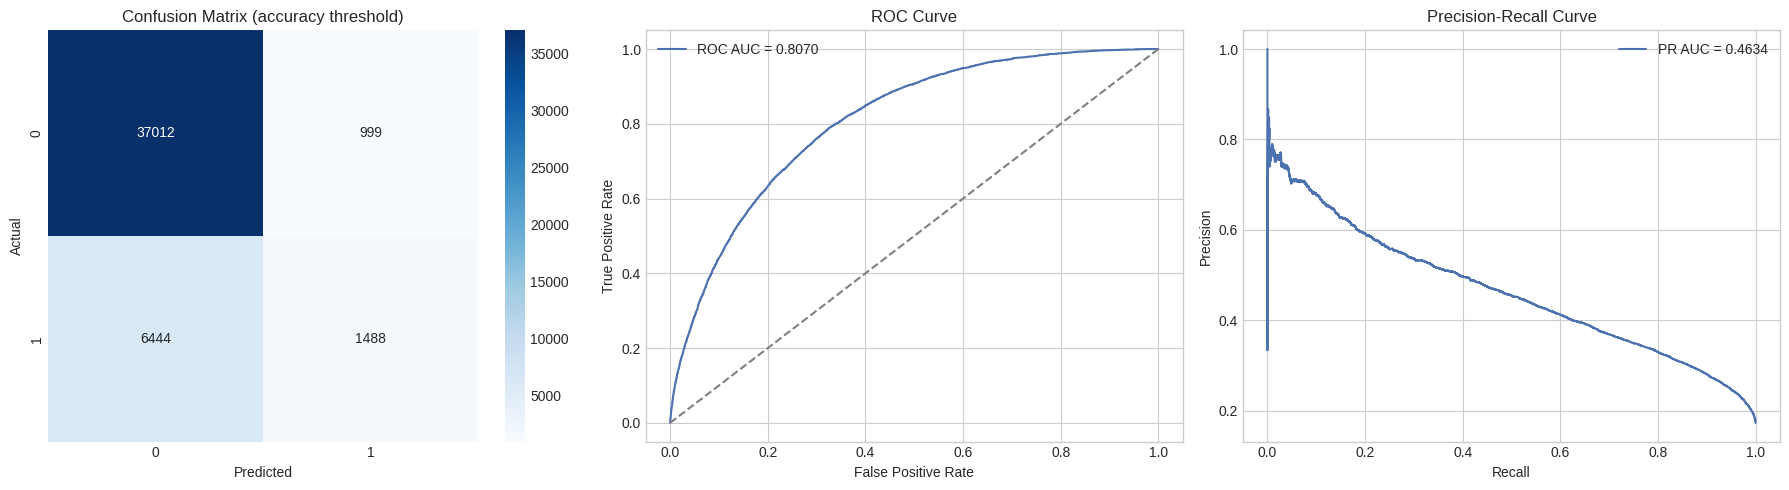

In [7]:
def metric_row(y_true, y_probability, threshold, label):
    y_hat = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    return {
        "label": label,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_hat),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_hat),
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "ppv_precision": ppv,
        "npv": npv,
        "f1": f1_score(y_true, y_hat),
        "mcc": matthews_corrcoef(y_true, y_hat),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc": average_precision_score(y_true, y_probability),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


best_pipeline = search.best_estimator_

X_fit, X_threshold, y_fit, y_threshold = train_test_split(
    X_train[SELECTED_FEATURES],
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

threshold_pipeline = clone(best_pipeline)
threshold_pipeline.fit(X_fit, y_fit)
threshold_proba = threshold_pipeline.predict_proba(X_threshold)[:, 1]

threshold_rows = [
    metric_row(y_threshold, threshold_proba, threshold, "training_validation")
    for threshold in np.linspace(0.05, 0.95, 181)
]
threshold_table = pd.DataFrame(threshold_rows)

threshold_sort_orders = {
    "accuracy": ["accuracy", "mcc", "f1"],
    "f1": ["f1", "mcc", "balanced_accuracy"],
    "mcc": ["mcc", "f1", "balanced_accuracy"],
    "balanced_accuracy": ["balanced_accuracy", "mcc", "f1"],
}

best_thresholds = {}
for metric_name, sort_columns in threshold_sort_orders.items():
    best_thresholds[metric_name] = float(
        threshold_table.sort_values(sort_columns, ascending=False).iloc[0]["threshold"]
    )

print("Best validation thresholds:")
display(pd.Series(best_thresholds, name="threshold"))

display(threshold_table.sort_values([PRIMARY_THRESHOLD_METRIC, "f1", "mcc"], ascending=False).head(10))

DECISION_THRESHOLD = best_thresholds.get(PRIMARY_THRESHOLD_METRIC, best_thresholds["mcc"])
print(f"Selected decision threshold optimized for {PRIMARY_THRESHOLD_METRIC}:", DECISION_THRESHOLD)

best_pipeline.fit(X_train[SELECTED_FEATURES], y_train)
y_proba = best_pipeline.predict_proba(X_test[SELECTED_FEATURES])[:, 1]
y_pred = (y_proba >= DECISION_THRESHOLD).astype(int)

final_metric_rows = [metric_row(y_test, y_proba, 0.50, "test_threshold_0_50")]
for metric_name, threshold in best_thresholds.items():
    final_metric_rows.append(metric_row(y_test, y_proba, threshold, f"test_{metric_name}_tuned_threshold"))

xgboost_final_metrics = pd.DataFrame(final_metric_rows)
display(xgboost_final_metrics)

print("Classification report at selected threshold:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title(f"Confusion Matrix ({PRIMARY_THRESHOLD_METRIC} threshold)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_proba):.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(recall_vals, precision_vals, label=f"PR AUC = {average_precision_score(y_test, y_proba):.4f}")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Built-in Importance, SHAP, and LIME

XGBoost gain importance is a fast model-native diagnostic. SHAP gives a stronger additive explanation of how each transformed feature contributes to the predicted diabetes probability.

,encoded_feature,source_feature,importance
1,num__highbp,highbp,0.478958
0,num__genhlth,genhlth,0.156409
4,num__highchol,highchol,0.105549
2,num__bmi,bmi,0.056495
5,num__age,age,0.055707
3,num__diffwalk,diffwalk,0.044514
6,num__heartdiseaseorattack,heartdiseaseorattack,0.032941
8,num__cholcheck,cholcheck,0.030547
9,num__sex,sex,0.014765
11,num__stroke,stroke,0.010014


,source_feature,importance
0,highbp,0.478958
1,genhlth,0.156409
2,highchol,0.105549
3,bmi,0.056495
4,age,0.055707
5,diffwalk,0.044514
6,heartdiseaseorattack,0.032941
7,cholcheck,0.030547
8,sex,0.014765
9,stroke,0.010014


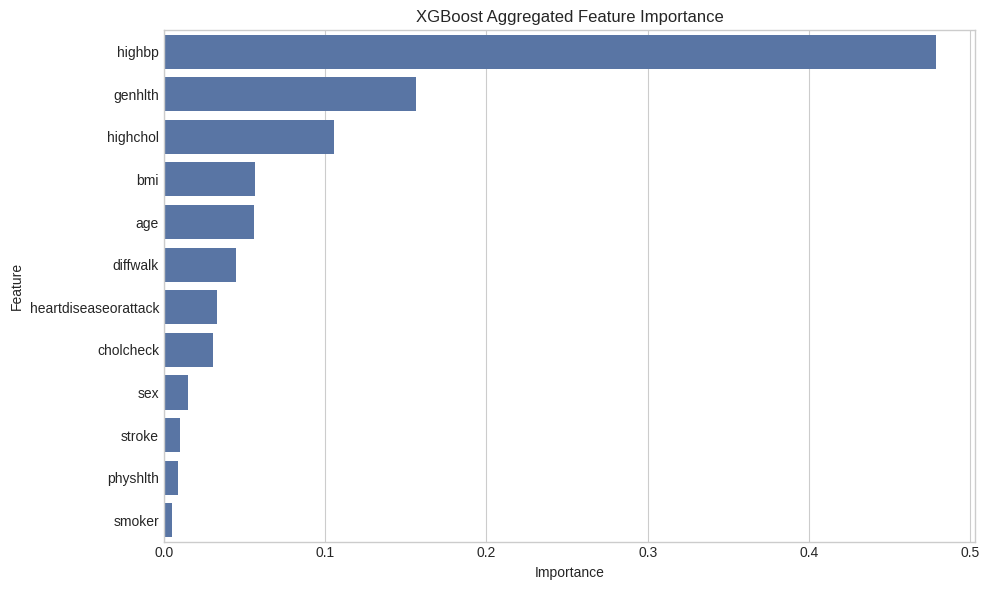

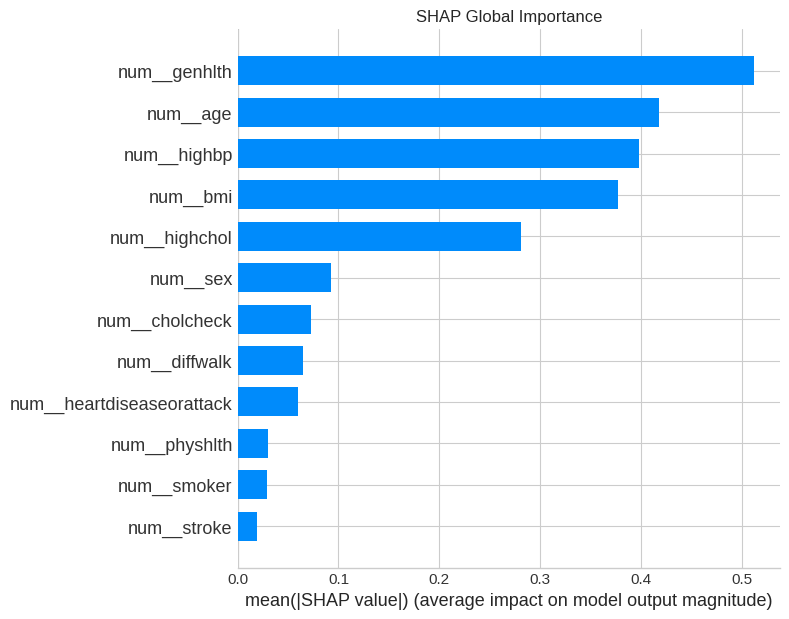

LIME explained row index: 205755
Actual class: 1
Predicted diabetes probability: 0.8138


,feature_condition,lime_weight_for_diabetes
0,bmi > 32.00,0.066855
1,genhlth > 3.00,0.065510
2,heartdiseaseorattack > 0.00,0.044223
3,age > 10.00,0.042322
4,0.00 < highchol <= 1.00,0.037390
5,0.00 < highbp <= 1.00,0.036847
6,physhlth > 4.00,0.023839
7,diffwalk > 0.00,0.021175
8,stroke > 0.00,0.010499
9,0.00 < sex <= 1.00,0.010195


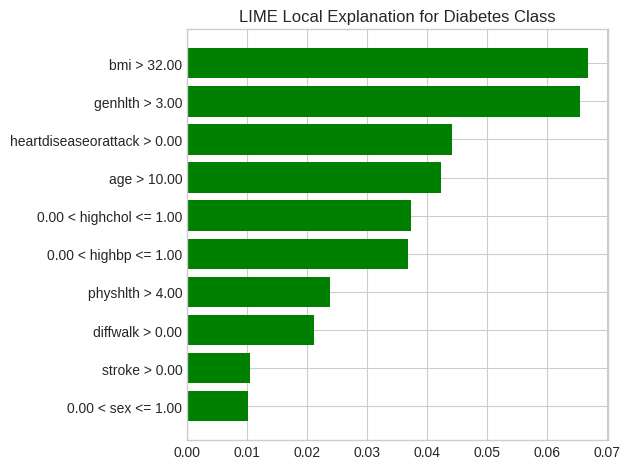

In [8]:
def clean_transformed_feature_name(transformed_name, original_features):
    name = transformed_name.replace("num__", "").replace("cat__", "")
    for original in sorted(original_features, key=len, reverse=True):
        if name == original or name.startswith(original + "_"):
            return original
    return name

feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
clean_feature_names = [clean_transformed_feature_name(name, SELECTED_FEATURES) for name in feature_names]
fitted_xgb_model = best_pipeline.named_steps["model"]

encoded_importance_table = pd.DataFrame({
    "encoded_feature": feature_names,
    "source_feature": clean_feature_names,
    "importance": fitted_xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

xgb_importance = (
    encoded_importance_table
    .groupby("source_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(encoded_importance_table.head(20))
display(xgb_importance.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance.head(15), x="importance", y="source_feature")
plt.title("XGBoost Aggregated Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

X_explain = X_test[SELECTED_FEATURES].sample(min(EXPLAIN_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
X_explain_transformed = best_pipeline.named_steps["preprocessor"].transform(X_explain)

explainer = shap.TreeExplainer(fitted_xgb_model)
shap_values = explainer.shap_values(X_explain_transformed)

if isinstance(shap_values, list):
    shap_matrix = shap_values[-1]
elif hasattr(shap_values, "values"):
    shap_matrix = shap_values.values
    if shap_matrix.ndim == 3:
        shap_matrix = shap_matrix[:, :, -1]
else:
    shap_matrix = shap_values

shap.summary_plot(
    shap_matrix,
    features=X_explain_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Global Importance")
plt.tight_layout()
plt.show()

# LIME local explanation for one high-risk positive case.
lime_training_frame = X_train[SELECTED_FEATURES].sample(
    min(LIME_TRAIN_SAMPLE_SIZE, len(X_train)),
    random_state=RANDOM_STATE,
)

lime_explainer = LimeTabularExplainer(
    training_data=lime_training_frame.to_numpy(dtype=float),
    feature_names=SELECTED_FEATURES,
    class_names=["no_diabetes", "diabetes"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

probability_series = pd.Series(y_proba, index=X_test.index, name="predicted_diabetes_probability")
positive_test_indices = y_test[y_test == 1].index.intersection(X_test.index)
if len(positive_test_indices) > 0:
    lime_index = probability_series.loc[positive_test_indices].sort_values(ascending=False).index[0]
else:
    lime_index = probability_series.sort_values(ascending=False).index[0]

lime_instance = X_test.loc[lime_index, SELECTED_FEATURES]

def lime_predict_proba(values):
    lime_frame = pd.DataFrame(values, columns=SELECTED_FEATURES)
    return best_pipeline.predict_proba(lime_frame)

lime_explanation = lime_explainer.explain_instance(
    data_row=lime_instance.to_numpy(dtype=float),
    predict_fn=lime_predict_proba,
    num_features=min(10, len(SELECTED_FEATURES)),
    labels=(1,),
)

print("LIME explained row index:", lime_index)
print("Actual class:", int(y_test.loc[lime_index]))
print("Predicted diabetes probability:", round(float(probability_series.loc[lime_index]), 4))

lime_table = pd.DataFrame(
    lime_explanation.as_list(label=1),
    columns=["feature_condition", "lime_weight_for_diabetes"],
)
display(lime_table)

fig = lime_explanation.as_pyplot_figure(label=1)
plt.title("LIME Local Explanation for Diabetes Class")
plt.tight_layout()
plt.show()

## 7. Permutation and Drop-Column Importance

Permutation importance measures how much test ROC AUC falls when a feature is shuffled. Drop-column importance retrains the model without one feature at a time on a training subset, which is slower but often more faithful when features are correlated.

,feature,permutation_importance_mean,permutation_importance_std
0,genhlth,0.044736,0.005706
1,bmi,0.042700,0.007946
2,age,0.033488,0.003320
3,highbp,0.015983,0.002685
4,highchol,0.011231,0.003744
5,cholcheck,0.007580,0.002836
6,sex,0.004363,0.001014
7,diffwalk,0.003931,0.001107
8,physhlth,0.002894,0.000683
9,heartdiseaseorattack,0.002893,0.001069


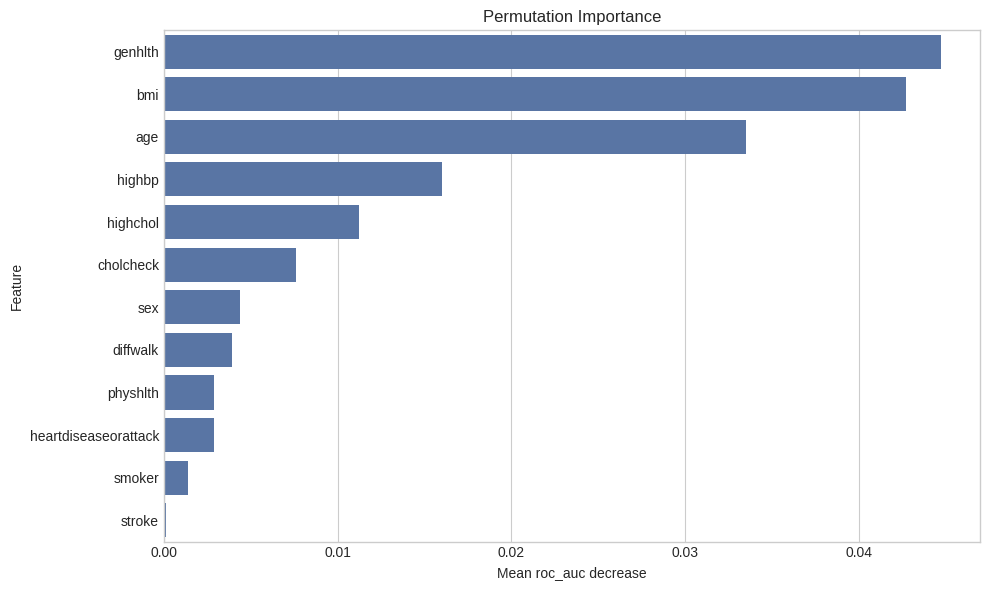

,dropped_feature,base_auc,auc_without_feature,drop_column_importance
0,genhlth,0.807729,0.789426,0.018303
1,bmi,0.807729,0.790270,0.017459
2,age,0.807729,0.794890,0.012839
3,highbp,0.807729,0.800440,0.007289
4,highchol,0.807729,0.801704,0.006025
5,cholcheck,0.807729,0.806299,0.001430
6,heartdiseaseorattack,0.807729,0.806514,0.001215
7,sex,0.807729,0.806934,0.000795
8,diffwalk,0.807729,0.807199,0.000530
9,physhlth,0.807729,0.807254,0.000474


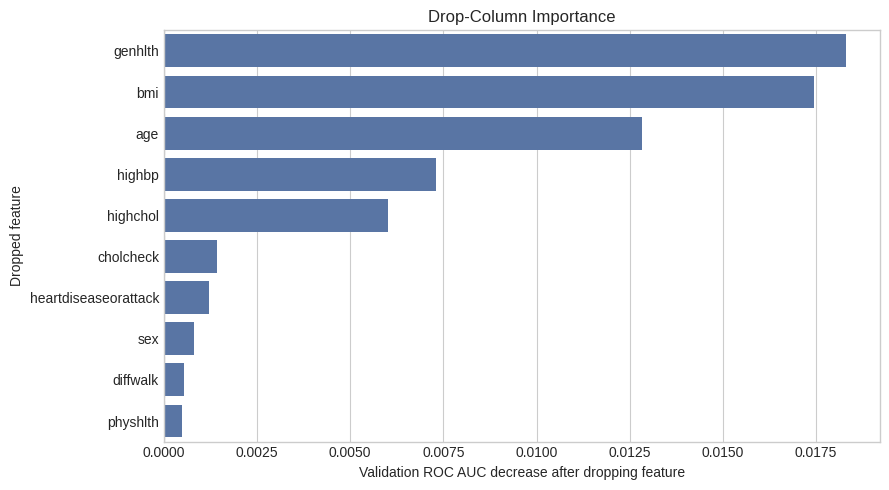

In [9]:
X_perm = X_test[SELECTED_FEATURES].sample(min(EXPLAIN_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]

perm_result = permutation_importance(
    best_pipeline,
    X_perm,
    y_perm,
    scoring=MODEL_SELECTION_SCORING,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

permutation_importance_table = (
    pd.DataFrame({
        "feature": SELECTED_FEATURES,
        "permutation_importance_mean": perm_result.importances_mean,
        "permutation_importance_std": perm_result.importances_std,
    })
    .sort_values("permutation_importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(permutation_importance_table.head(25))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=permutation_importance_table.head(15),
    x="permutation_importance_mean",
    y="feature",
)
plt.title("Permutation Importance")
plt.xlabel(f"Mean {MODEL_SELECTION_SCORING} decrease")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Drop-column importance is slower, so it is limited to the strongest permutation candidates.
drop_candidates = permutation_importance_table.head(DROP_COLUMN_TOP_N)["feature"].tolist()
X_dc_train, X_dc_valid, y_dc_train, y_dc_valid = train_test_split(
    X_train[SELECTED_FEATURES],
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
X_dc_train, y_dc_train = stratified_limit(X_dc_train, y_dc_train, DROP_COLUMN_SAMPLE_LIMIT)

base_drop_pipeline = clone(best_pipeline)
base_drop_pipeline.fit(X_dc_train[SELECTED_FEATURES], y_dc_train)
base_drop_proba = base_drop_pipeline.predict_proba(X_dc_valid[SELECTED_FEATURES])[:, 1]
base_drop_auc = roc_auc_score(y_dc_valid, base_drop_proba)

best_model_template = clone(best_pipeline.named_steps["model"])
drop_rows = []
for feature in drop_candidates:
    reduced_features = [candidate for candidate in SELECTED_FEATURES if candidate != feature]
    reduced_pipeline = make_xgb_pipeline(reduced_features, model=clone(best_model_template))
    reduced_pipeline.fit(X_dc_train[reduced_features], y_dc_train)
    reduced_proba = reduced_pipeline.predict_proba(X_dc_valid[reduced_features])[:, 1]
    reduced_auc = roc_auc_score(y_dc_valid, reduced_proba)
    drop_rows.append({
        "dropped_feature": feature,
        "base_auc": base_drop_auc,
        "auc_without_feature": reduced_auc,
        "drop_column_importance": base_drop_auc - reduced_auc,
    })

drop_column_importance_table = (
    pd.DataFrame(drop_rows)
    .sort_values("drop_column_importance", ascending=False)
    .reset_index(drop=True)
)
display(drop_column_importance_table)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=drop_column_importance_table,
    x="drop_column_importance",
    y="dropped_feature",
)
plt.axvline(0, color="grey", linestyle="--")
plt.title("Drop-Column Importance")
plt.xlabel("Validation ROC AUC decrease after dropping feature")
plt.ylabel("Dropped feature")
plt.tight_layout()
plt.show()

## 8. PDP, ICE, and ALE

PDP shows the average modeled effect of a feature. ICE shows individual-level response curves. ALE is often more reliable when features are correlated because it estimates local changes inside observed feature intervals.

PDP/ALE numeric features: ['genhlth', 'bmi', 'age']


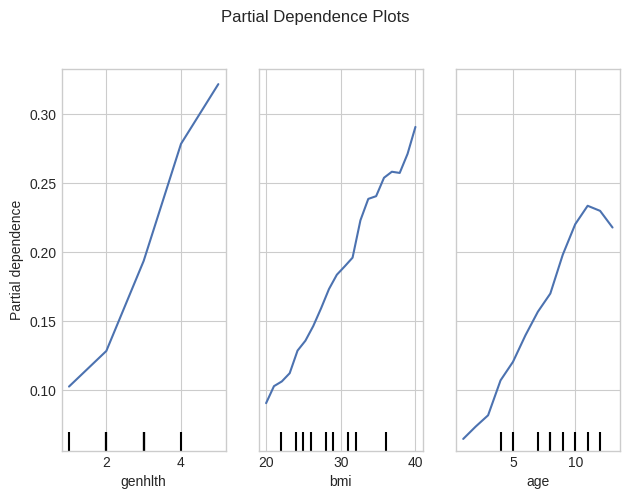

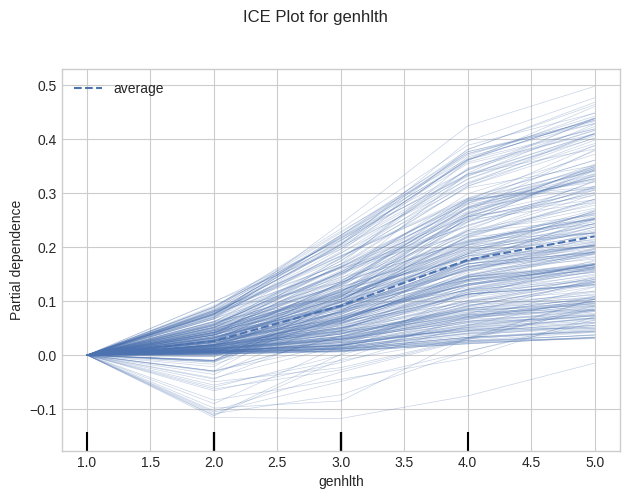

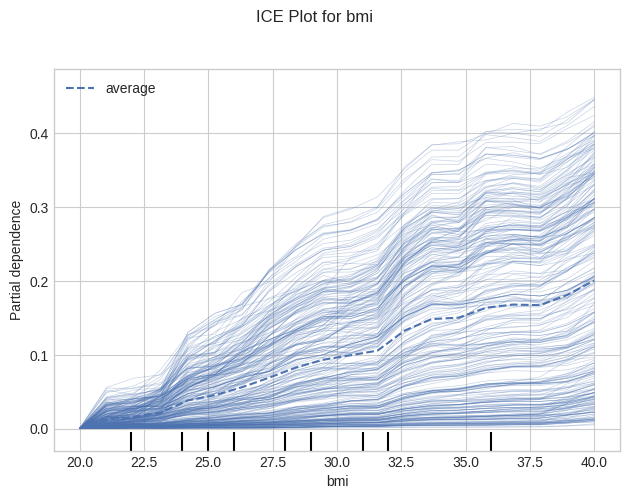

In [10]:
def top_numeric_explain_features(priority_tables, max_features=4, min_unique=3):
    ordered = []
    for table, feature_column in priority_tables:
        if table is None or table.empty:
            continue
        for feature in table[feature_column].tolist():
            if feature in SELECTED_FEATURES and feature not in ordered:
                if pd.api.types.is_numeric_dtype(X_train[feature]) and X_train[feature].nunique(dropna=True) >= min_unique:
                    ordered.append(feature)
            if len(ordered) >= max_features:
                return ordered
    for feature in SELECTED_FEATURES:
        if feature not in ordered:
            if pd.api.types.is_numeric_dtype(X_train[feature]) and X_train[feature].nunique(dropna=True) >= min_unique:
                ordered.append(feature)
        if len(ordered) >= max_features:
            break
    return ordered

pdp_features = top_numeric_explain_features([
    (permutation_importance_table, "feature"),
    (xgb_importance.rename(columns={"source_feature": "feature"}), "feature"),
    (feature_ranking, "feature"),
], max_features=3)

print("PDP/ALE numeric features:", pdp_features)

X_pdp = X_test[SELECTED_FEATURES].sample(min(EXPLAIN_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)

if pdp_features:
    PartialDependenceDisplay.from_estimator(
        best_pipeline,
        X_pdp,
        features=pdp_features,
        kind="average",
        grid_resolution=20,
        response_method="predict_proba",
    )
    plt.suptitle("Partial Dependence Plots", y=1.03)
    plt.tight_layout()
    plt.show()

ice_features = pdp_features[:2]
for feature in ice_features:
    try:
        PartialDependenceDisplay.from_estimator(
            best_pipeline,
            X_pdp,
            features=[feature],
            kind="both",
            subsample=min(ICE_SAMPLE_SIZE, len(X_pdp)),
            centered=True,
            grid_resolution=20,
            random_state=RANDOM_STATE,
            response_method="predict_proba",
        )
    except TypeError:
        PartialDependenceDisplay.from_estimator(
            best_pipeline,
            X_pdp,
            features=[feature],
            kind="individual",
            subsample=min(ICE_SAMPLE_SIZE, len(X_pdp)),
            grid_resolution=20,
            random_state=RANDOM_STATE,
            response_method="predict_proba",
        )
    plt.suptitle(f"ICE Plot for {feature}", y=1.03)
    plt.tight_layout()
    plt.show()

,feature,bin_center,ale,bin_count
0,genhlth,1.5,-0.107307,224
1,genhlth,2.5,-0.045703,505
2,genhlth,3.5,0.044503,505
3,genhlth,4.5,0.092642,266
4,bmi,19.0,-0.066422,136
5,bmi,23.0,-0.049381,159
6,bmi,24.5,-0.043015,110
7,bmi,25.5,-0.032884,96
8,bmi,27.0,-0.007467,247
9,bmi,28.5,0.003027,90


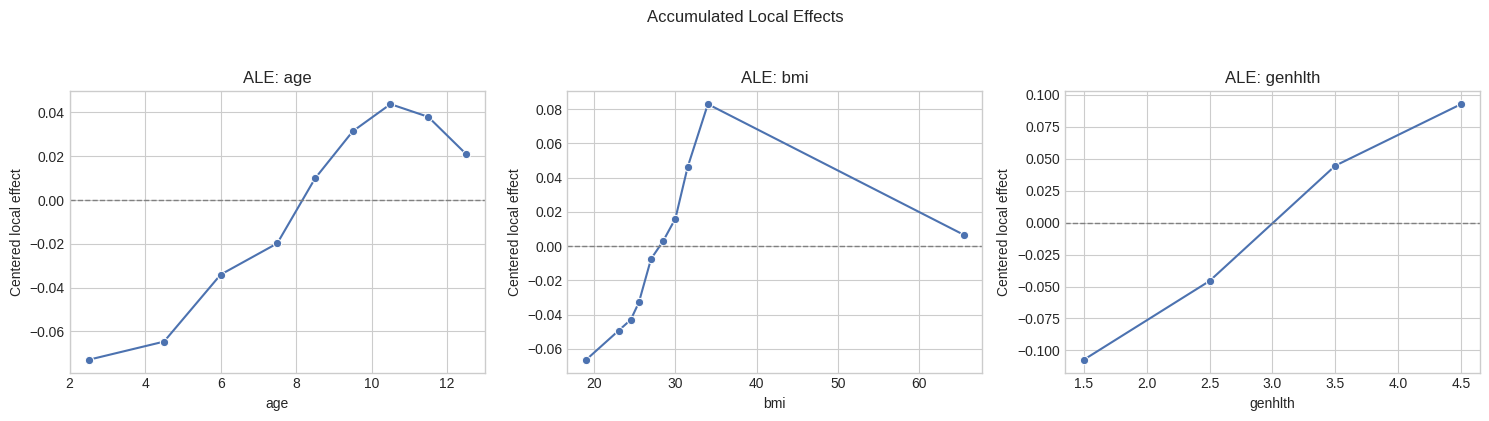

In [11]:
def compute_ale_1d(estimator, data, feature, bins=10):
    work = data.copy()
    values = pd.to_numeric(work[feature], errors="coerce").dropna()
    quantiles = np.unique(np.quantile(values, np.linspace(0, 1, bins + 1)))

    if len(quantiles) < 3:
        unique_values = np.sort(values.unique())
        if len(unique_values) < 3:
            return pd.DataFrame(columns=["feature", "bin_center", "ale", "bin_count"])
        quantiles = unique_values

    interval_effects = []
    interval_centers = []
    interval_counts = []

    for index, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
        if lower == upper:
            continue
        if index == len(quantiles) - 2:
            mask = (work[feature] >= lower) & (work[feature] <= upper)
        else:
            mask = (work[feature] >= lower) & (work[feature] < upper)

        if mask.sum() == 0:
            continue

        lower_frame = work.loc[mask].copy()
        upper_frame = work.loc[mask].copy()
        lower_frame[feature] = lower
        upper_frame[feature] = upper

        lower_pred = estimator.predict_proba(lower_frame)[:, 1]
        upper_pred = estimator.predict_proba(upper_frame)[:, 1]

        interval_effects.append(np.mean(upper_pred - lower_pred))
        interval_centers.append((lower + upper) / 2)
        interval_counts.append(int(mask.sum()))

    if not interval_effects:
        return pd.DataFrame(columns=["feature", "bin_center", "ale", "bin_count"])

    ale_values = np.cumsum(interval_effects)
    ale_values = ale_values - np.average(ale_values, weights=interval_counts)

    return pd.DataFrame({
        "feature": feature,
        "bin_center": interval_centers,
        "ale": ale_values,
        "bin_count": interval_counts,
    })

ale_tables = []
for feature in pdp_features:
    feature_ale_table = compute_ale_1d(best_pipeline, X_pdp, feature, bins=10)
    if not feature_ale_table.empty:
        ale_tables.append(feature_ale_table)

if ale_tables:
    ale_table = pd.concat(ale_tables, ignore_index=True)
    display(ale_table)

    feature_count = ale_table["feature"].nunique()
    fig, axes = plt.subplots(1, feature_count, figsize=(5 * feature_count, 4))
    if feature_count == 1:
        axes = [axes]
    for axis, (feature, feature_table) in zip(axes, ale_table.groupby("feature")):
        sns.lineplot(data=feature_table, x="bin_center", y="ale", marker="o", ax=axis)
        axis.axhline(0, color="grey", linestyle="--", linewidth=1)
        axis.set_title(f"ALE: {feature}")
        axis.set_xlabel(feature)
        axis.set_ylabel("Centered local effect")
    plt.suptitle("Accumulated Local Effects", y=1.04)
    plt.tight_layout()
    plt.show()
else:
    print("ALE skipped because no numeric feature had enough unique values.")

## 9. Feature Interaction H-Statistics

The H-statistic estimates how strongly two features interact in the fitted model. Values closer to 0 suggest mostly additive behavior; values closer to 1 suggest stronger interaction effects. This implementation uses a prediction-grid approximation so it is readable and Colab-friendly.

,feature_a,feature_b,h_statistic
0,bmi,age,0.241937
1,genhlth,bmi,0.204902
2,genhlth,age,0.164011
3,genhlth,physhlth,0.129763
4,age,physhlth,0.077769
5,bmi,physhlth,0.033823


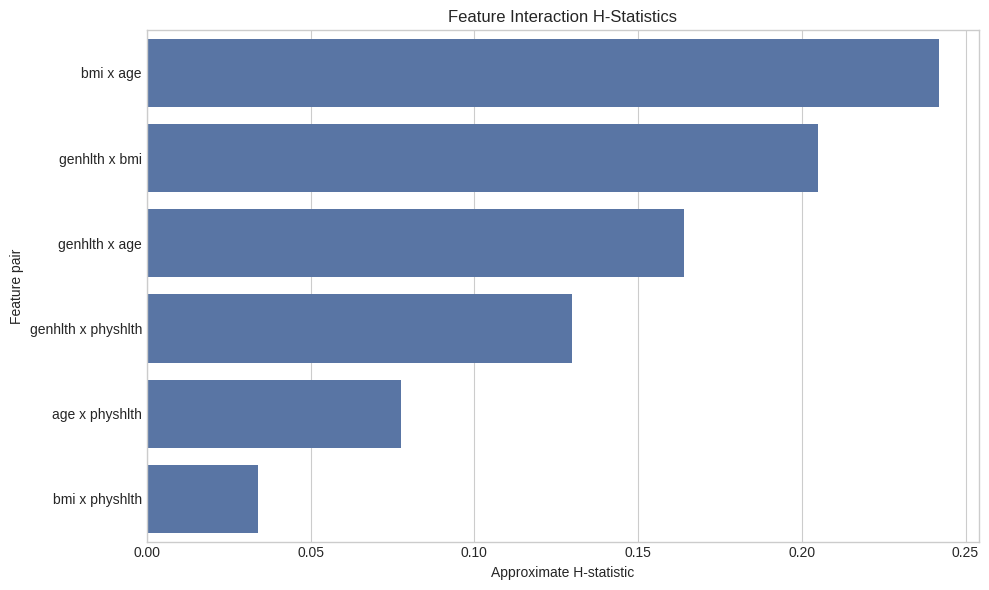

In [12]:
def feature_grid(data, feature, points=8):
    values = pd.to_numeric(data[feature], errors="coerce").dropna()
    if values.nunique() <= points:
        return np.sort(values.unique())
    return np.unique(np.quantile(values, np.linspace(0.05, 0.95, points)))


def mean_prediction_with_updates(estimator, background, updates):
    updated = background.copy()
    for feature, value in updates.items():
        updated[feature] = value
    return estimator.predict_proba(updated)[:, 1].mean()


def friedman_h_statistic_pair(estimator, background, feature_a, feature_b, grid_points=8):
    grid_a = feature_grid(background, feature_a, points=grid_points)
    grid_b = feature_grid(background, feature_b, points=grid_points)

    if len(grid_a) < 2 or len(grid_b) < 2:
        return np.nan

    pd_a = np.array([
        mean_prediction_with_updates(estimator, background, {feature_a: value_a})
        for value_a in grid_a
    ])
    pd_b = np.array([
        mean_prediction_with_updates(estimator, background, {feature_b: value_b})
        for value_b in grid_b
    ])
    pd_ab = np.array([
        [
            mean_prediction_with_updates(estimator, background, {feature_a: value_a, feature_b: value_b})
            for value_b in grid_b
        ]
        for value_a in grid_a
    ])

    pd_a_centered = pd_a - pd_a.mean()
    pd_b_centered = pd_b - pd_b.mean()
    pd_ab_centered = pd_ab - pd_ab.mean()

    interaction_component = pd_ab_centered - pd_a_centered[:, None] - pd_b_centered[None, :]
    numerator = np.sum(interaction_component ** 2)
    denominator = np.sum(pd_ab_centered ** 2)

    if denominator == 0:
        return np.nan

    h_squared = np.clip(numerator / denominator, 0, 1)
    return float(np.sqrt(h_squared))

hstat_features = top_numeric_explain_features([
    (permutation_importance_table, "feature"),
    (xgb_importance.rename(columns={"source_feature": "feature"}), "feature"),
    (feature_ranking, "feature"),
], max_features=HSTAT_TOP_N)

X_hstat = X_test[SELECTED_FEATURES].sample(min(HSTAT_BACKGROUND_SIZE, len(X_test)), random_state=RANDOM_STATE)

h_rows = []
for feature_a, feature_b in combinations(hstat_features, 2):
    h_rows.append({
        "feature_a": feature_a,
        "feature_b": feature_b,
        "h_statistic": friedman_h_statistic_pair(best_pipeline, X_hstat, feature_a, feature_b, grid_points=8),
    })

h_statistics = (
    pd.DataFrame(h_rows)
    .sort_values("h_statistic", ascending=False)
    .reset_index(drop=True)
)
display(h_statistics)

if not h_statistics.empty:
    plt.figure(figsize=(10, 6))
    plot_table = h_statistics.copy()
    plot_table["pair"] = plot_table["feature_a"] + " x " + plot_table["feature_b"]
    sns.barplot(data=plot_table, x="h_statistic", y="pair")
    plt.title("Feature Interaction H-Statistics")
    plt.xlabel("Approximate H-statistic")
    plt.ylabel("Feature pair")
    plt.tight_layout()
    plt.show()

## Paper Comparison Notes for Report

**Paper to cite:** Khurshid MR, Manzoor S, Sadiq T, Hussain L, Khan MS, Dutta AK (2025), *Unveiling diabetes onset: Optimized XGBoost with Bayesian optimization for enhanced prediction*, PLOS ONE 20(1): e0310218. https://doi.org/10.1371/journal.pone.0310218

**Paper result to compare against:** the PLOS ONE abstract reports grid-search XGBoost accuracy 97.24%, F1-score 95.72%, and MCC 81.02%; Bayesian-optimized XGBoost reached accuracy 97.26%, F1-score 95.72%, and MCC 81.18%.

## Current Modeling Notes
- No feature engineering is used. The notebook keeps original BRFSS fields only after converting `diabetes_012` to the binary target.
- Removed low-correlation or low/negative-impact fields: `income`, `fruits`, `veggies`, `menthlth`, `anyhealthcare`, `nodocbccost`, `hvyalcoholconsump`, `physactivity`, and `education`.
- The default selected threshold is optimized for accuracy. Other thresholds are still reported in `xgboost_final_metrics` for recall/F1/MCC discussion.

After running this notebook in Colab, record these outputs in the report:
- `feature_ranking`: correlation, ANOVA, and mutual information feature rankings after removals.
- `preliminary_permutation_importance`: validation-only feature impact used before final tuning.
- `feature_selection_scorecard`: which feature set worked best before Bayesian optimization.
- `bayes_results`: Bayesian optimization trials and best parameters.
- `xgboost_final_metrics`: final test metrics under fixed and tuned thresholds.
- `xgb_importance`, `permutation_importance_table`, and `drop_column_importance_table`: best features.
- SHAP, LIME, PDP, ICE, ALE, and `h_statistics`: explainability evidence.

## Comparison Caveat
This notebook uses the BRFSS `diabetes_012_health_indicators_BRFSS2015.csv` file only. Do not compare raw accuracy directly against the paper as if the dataset were identical. Compare the workflow: preprocessing, Bayesian XGBoost tuning, feature selection, evaluation metrics, and explainability.